# Análisis de `compas-scores-two-years.csv`

<!-- Objetivo: analizar el CSV de COMPAS, revisar correlaciones y estimar qué variables explican mejor `two_year_recid` usando Random Forest.

**Variable objetivo:**

```text
two_year_recid = 1  -> hubo re-arresto/reincidencia observada en dos años
two_year_recid = 0  -> no hubo re-arresto/reincidencia observada en dos años
```

El análisis evita usar variables que claramente contienen información posterior al evento, como columnas `r_*`, `vr_*`, `event`, `end`, etc. Usarlas inflaría artificialmente el desempeño del modelo por fuga de información. -->


In [20]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

CSV_PATH = Path("data//raw//compas-scores-two-years.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("data//raw/compas-scores-two-years.csv")

OUTPUT_DIR = Path("data//salidas_analisis_compas")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(CSV_PATH)
print(f"Archivo: {CSV_PATH}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
display(df.head(3))


Archivo: data/raw/compas-scores-two-years.csv
Filas: 7,214
Columnas: 53


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1


## 1. Revisión rápida del dataset

Primero revisamos tipos de datos, valores faltantes y distribución de la variable objetivo.

In [21]:
resumen = pd.DataFrame({
    "variable": df.columns,
    "tipo": [str(df[c].dtype) for c in df.columns],
    "faltantes": [df[c].isna().sum() for c in df.columns],
    "% faltantes": [100 * df[c].isna().mean() for c in df.columns],
    "valores_unicos": [df[c].nunique(dropna=True) for c in df.columns]
}).sort_values("% faltantes", ascending=False)

print("Distribución de two_year_recid:")
display(df["two_year_recid"].value_counts(dropna=False).rename_axis("two_year_recid").to_frame("conteo"))

display(resumen.head(20))
resumen.to_csv(OUTPUT_DIR / "resumen_variables.csv", index=False)


Distribución de two_year_recid:


,conteo
two_year_recid,
0,3963
1,3251


,variable,tipo,faltantes,% faltantes,valores_unicos
32,violent_recid,float64,7214,100.000000,0
35,vr_charge_degree,object,6395,88.647075,9
36,vr_offense_date,object,6395,88.647075,570
34,vr_case_number,object,6395,88.647075,819
37,vr_charge_desc,object,6395,88.647075,83
20,c_arrest_date,object,6077,84.238980,580
30,r_jail_in,object,4898,67.895758,972
27,r_days_from_arrest,float64,4898,67.895758,201
31,r_jail_out,object,4898,67.895758,938
29,r_charge_desc,object,3801,52.689215,340


## 2. Tabla de correlaciones

La correlación de Pearson solo aplica directamente a variables numéricas. 

In [22]:
# Variables numéricas útiles y disponibles antes/durante la evaluación.
corr_cols = [
    "two_year_recid",
    "age",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "days_b_screening_arrest",
    "c_days_from_compas",
    "decile_score",
    "v_decile_score",
]

corr_cols = [c for c in corr_cols if c in df.columns]
corr_data = df[corr_cols].copy()

corr_matrix = corr_data.corr(numeric_only=True).round(3)
print("Matriz de correlaciones:")
display(corr_matrix)

corr_matrix.to_csv(OUTPUT_DIR / "tabla_correlaciones.csv")

corr_target = (
    corr_matrix["two_year_recid"]
    .drop("two_year_recid")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlacion_con_two_year_recid")
)
print("Correlación con two_year_recid, ordenada por valor absoluto:")
display(corr_target)

corr_target.to_csv(OUTPUT_DIR / "correlacion_con_objetivo.csv")


Matriz de correlaciones:


,two_year_recid,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,decile_score,v_decile_score
two_year_recid,1.000,-0.190,0.093,0.109,0.108,0.275,0.024,-0.068,0.351,0.296
age,-0.190,1.000,-0.066,-0.117,-0.155,0.143,-0.044,0.087,-0.388,-0.576
juv_fel_count,0.093,-0.066,1.000,0.089,0.047,0.179,0.013,0.003,0.178,0.173
juv_misd_count,0.109,-0.117,0.089,1.000,0.272,0.244,0.011,0.007,0.216,0.206
juv_other_count,0.108,-0.155,0.047,0.272,1.000,0.104,0.007,0.002,0.183,0.202
priors_count,0.275,0.143,0.179,0.244,0.104,1.000,0.004,0.015,0.435,0.209
days_b_screening_arrest,0.024,-0.044,0.013,0.011,0.007,0.004,1.000,0.088,0.046,0.055
c_days_from_compas,-0.068,0.087,0.003,0.007,0.002,0.015,0.088,1.000,0.030,-0.006
decile_score,0.351,-0.388,0.178,0.216,0.183,0.435,0.046,0.030,1.000,0.776
v_decile_score,0.296,-0.576,0.173,0.206,0.202,0.209,0.055,-0.006,0.776,1.000


Correlación con two_year_recid, ordenada por valor absoluto:


,correlacion_con_two_year_recid
decile_score,0.351
v_decile_score,0.296
priors_count,0.275
age,-0.190
juv_misd_count,0.109
juv_other_count,0.108
juv_fel_count,0.093
c_days_from_compas,-0.068
days_b_screening_arrest,0.024


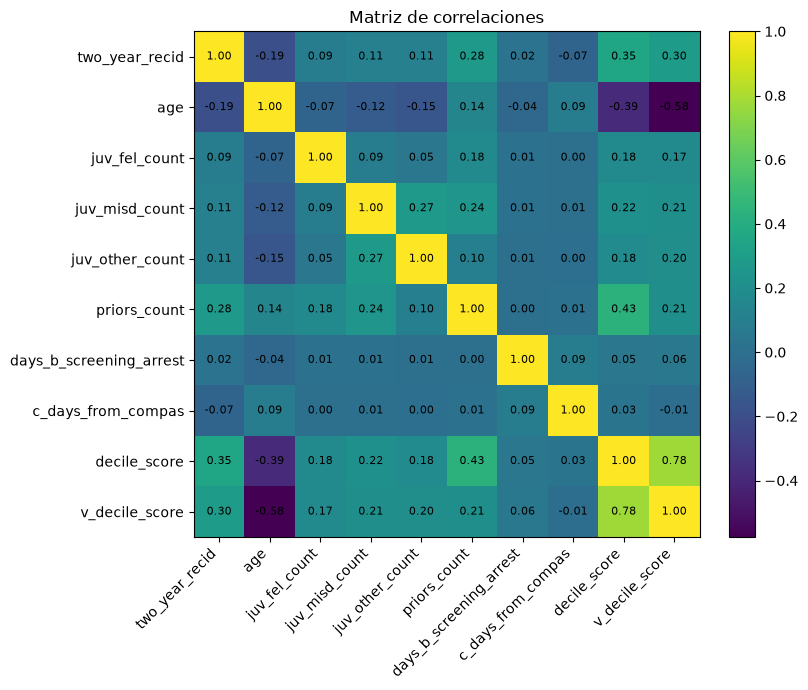

In [23]:
# Heatmap simple de la matriz de correlación.
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Matriz de correlaciones")
plt.tight_layout()
plt.show()


## 3. Selección de variables para Random Forest

Se excluyen identificadores y columnas posteriores al resultado. 

Variables excluidas por fuga o identificación: nombres, números de caso, `r_*`, `vr_*`, `is_recid`, `event`, `end`, fechas posteriores y la propia variable objetivo.

In [24]:
target = "two_year_recid"

candidate_features = [
    "sex",
    "age",
    "race",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "days_b_screening_arrest",
    "c_days_from_compas",
    "c_charge_degree",
    # "c_charge_desc",
    # "decile_score",
    # "score_text",
    # "v_decile_score",
    # "v_score_text",
]

features = [c for c in candidate_features if c in df.columns]
model_df = df[features + [target]].copy()
model_df = model_df.dropna(subset=[target])
model_df[target] = model_df[target].astype(int)

num_features = [c for c in features if pd.api.types.is_numeric_dtype(model_df[c])]
cat_features = [c for c in features if c not in num_features]

# Imputación simple.
for c in num_features:
    model_df[c] = model_df[c].fillna(model_df[c].median())
for c in cat_features:
    model_df[c] = model_df[c].fillna("Missing").astype(str)

X_raw = model_df[features]
y = model_df[target]

# Codificación one-hot para variables categóricas.
X = pd.get_dummies(X_raw, columns=cat_features, prefix_sep="__", drop_first=False)

print(f"Filas usadas: {len(model_df):,}")
print(f"Variables originales usadas: {len(features)}")
print(f"Columnas tras one-hot: {X.shape[1]}")
print("Variables originales:")
print(features)


Filas usadas: 7,214
Variables originales usadas: 10
Columnas tras one-hot: 17
Variables originales:
['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_days_from_compas', 'c_charge_degree']


## 4. Random Forest

Se entrena un Random Forest para predecir `two_year_recid`. 

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]

metricas = pd.DataFrame({
    "métrica": ["accuracy", "f1", "roc_auc"],
    "valor": [
        accuracy_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, proba),
    ]
})
metricas["valor"] = metricas["valor"].round(4)

display(metricas)
print("Matriz de confusión [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, pred))
print()
print("Reporte de clasificación:")
print(classification_report(y_test, pred, digits=3))

metricas.to_csv(OUTPUT_DIR / "metricas_random_forest.csv", index=False)


,métrica,valor
0,accuracy,0.6757
1,f1,0.6341
2,roc_auc,0.7254


Matriz de confusión [[TN, FP], [FN, TP]]:
[[712 279]
 [306 507]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.699     0.718     0.709       991
           1      0.645     0.624     0.634       813

    accuracy                          0.676      1804
   macro avg      0.672     0.671     0.671      1804
weighted avg      0.675     0.676     0.675      1804



## 5. Variables más explicativas según Random Forest

Random Forest calcula importancia por reducción de impureza. Como las variables categóricas fueron convertidas a varias columnas one-hot, se agregan esas importancias para volver al nombre de la variable original.

In [26]:
importancias_encoded = pd.DataFrame({
    "variable_codificada": X.columns,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

# Agregar columnas one-hot a su variable original.
def original_name(col):
    return col.split("__")[0] if "__" in col else col

importancias_encoded["variable_original"] = importancias_encoded["variable_codificada"].map(original_name)

importancias_originales = (
    importancias_encoded
    .groupby("variable_original", as_index=False)["importancia"]
    .sum()
    .sort_values("importancia", ascending=False)
)
importancias_originales["importancia"] = importancias_originales["importancia"].round(4)

print("Variables más explicativas, agregadas por variable original:")
display(importancias_originales)

print("Top columnas codificadas específicas:")
display(importancias_encoded.head(20).round(4))

# importancias_originales.to_csv(OUTPUT_DIR / "importancias_random_forest_originales.csv", index=False)
# importancias_encoded.to_csv(OUTPUT_DIR / "importancias_random_forest_codificadas.csv", index=False)


Variables más explicativas, agregadas por variable original:


,variable_original,importancia
7,priors_count,0.3184
0,age,0.2933
2,c_days_from_compas,0.1012
3,days_b_screening_arrest,0.0971
8,race,0.0612
9,sex,0.0332
1,c_charge_degree,0.0325
6,juv_other_count,0.0319
5,juv_misd_count,0.0174
4,juv_fel_count,0.0137


Top columnas codificadas específicas:


,variable_codificada,importancia,variable_original
4,priors_count,0.3184,priors_count
0,age,0.2933,age
6,c_days_from_compas,0.1012,c_days_from_compas
5,days_b_screening_arrest,0.0971,days_b_screening_arrest
3,juv_other_count,0.0319,juv_other_count
9,race__African-American,0.0305,race
2,juv_misd_count,0.0174,juv_misd_count
8,sex__Male,0.0169,sex
16,c_charge_degree__M,0.0167,c_charge_degree
7,sex__Female,0.0163,sex


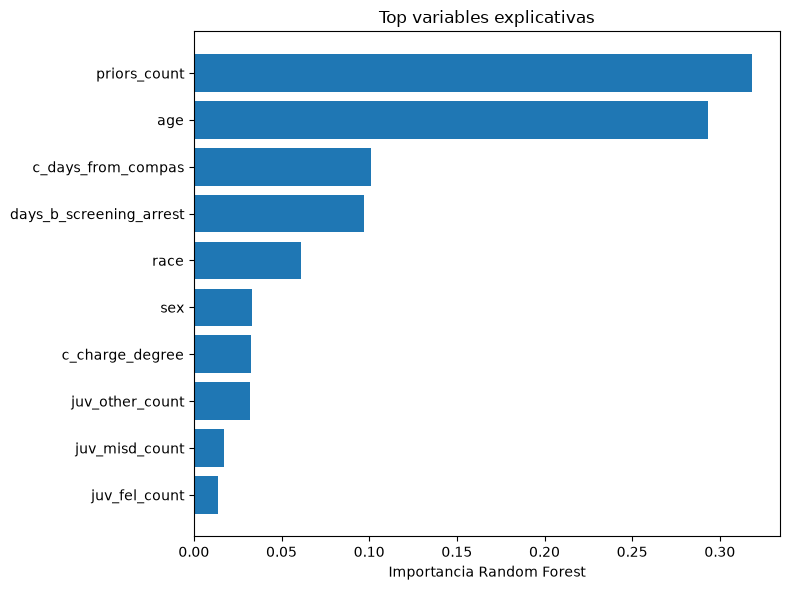

In [27]:
top = importancias_originales.head(15).sort_values("importancia")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["variable_original"], top["importancia"])
ax.set_xlabel("Importancia Random Forest")
ax.set_title("Top variables explicativas")
plt.tight_layout()
plt.show()
